# Sample Mini Project

The goal of this project is to study the correlation between male and female life expectancy and a country's GDP per capita. See the PowerPoint presentation for more details.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv('drive/My Drive/Notebook12/Indicators.csv')

Mounted at /content/drive


We want to use the most recent year of data, so now we find the most recent year of male and female life expectancy data and GDP data.

In [ ]:
indicatortext1 = 'Life expectancy at birth, male'
mask1 = data.IndicatorName.str.contains(indicatortext1)
most_recent_year1 = data[mask1].Year.max()

indicatortext2 = 'Life expectancy at birth, female'
mask2 = data.IndicatorName.str.contains(indicatortext2)
most_recent_year2 = data[mask2].Year.max()

indicatortext3 = 'GDP per capita \(constant 2005'
mask3 = data.IndicatorName.str.contains(indicatortext3)
most_recent_year3 = data[mask3].Year.max()

print (most_recent_year1, most_recent_year2, most_recent_year3)

2013 2013 2014


In [ ]:
# stage = data[mask1].Year.max()
# stage.head()

GDP data goes until 2014, but life expectancy data only goes to 2013, so we need to use 2013 as our year.

In [ ]:
year_use = np.min([most_recent_year1, most_recent_year2, most_recent_year3])
maskyear = data.Year == year_use

**Define three dataframes containing male life epectancy for each country in 2013, female life expectancy for each country in 2013, and GDP for each country in 2013.**

In [ ]:
stage1 = data[mask1 & maskyear][['CountryName','Value']]
stage1.columns=['CountryName','LifeExpectancyMale']

stage2 = data[mask2 & maskyear][['CountryName','Value']]
stage2.columns=['CountryName','LifeExpectancyFemale']

stage3 = data[mask3 & maskyear][['CountryName','Value']]
stage3.columns=['CountryName','GDP']

In [ ]:
# most_recent_year3.tails()
# stage1.tails()
# stage2.tails()


**Combine these three dataframes into a single dataframe, and get arrays of countries, life expectancies, and gdps.**

In [ ]:
combined=stage1.merge(stage2,on='CountryName', how='inner').merge(stage3,on='CountryName', how='inner')

countries = combined.CountryName.to_numpy()
life_male=combined.LifeExpectancyMale.to_numpy()
life_female=combined.LifeExpectancyFemale.to_numpy()
gdps=combined.GDP.to_numpy()
combined.head()

,CountryName,LifeExpectancyMale,LifeExpectancyFemale,GDP
0,Arab World,68.848383,72.536117,4546.146799
1,Caribbean small states,69.183365,74.757382,7415.535253
2,Central Europe and the Baltics,72.475938,79.973818,10331.281882
3,East Asia & Pacific (all income levels),72.697030,76.524546,6283.824734
4,East Asia & Pacific (developing only),71.957997,75.466062,3070.399647


**Do an exploratory plot of male life expectancy versus GDP per capita and compute a correlation coefficeint. Use a logarithmic x-axis for GDP because the range is so large: use "plt.xscale('log')". Look for outliers. There seem to be three low outliers.**

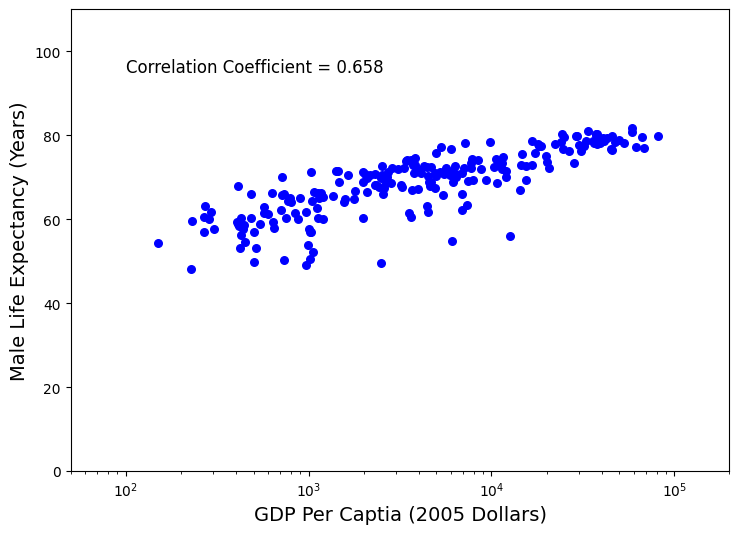

In [ ]:
plt.figure(figsize=(8.5,6))

plt.scatter(gdps,life_male,c='blue',s=30)
plt.axis([50,200000,0,110])
plt.xscale('log') #plots x-axis on a logarithmic scale.
plt.xlabel('GDP Per Captia (2005 Dollars)',fontsize=14)
plt.ylabel('Male Life Expectancy (Years)',fontsize=14)

#Use plt.text to annotate plot.
plt.text(100,95,f'Correlation Coefficient = {np.corrcoef(life_male,gdps)[0,1]:.3f}',fontsize=12)

plt.show()

**Do an exploratory plot of female life expectancy versus GDP per capita and compute a correlation coefficeint. Use a logarithmic x-axis for GDP because the range is so large. Look for outliers. There seem to be three low outliers here also.**

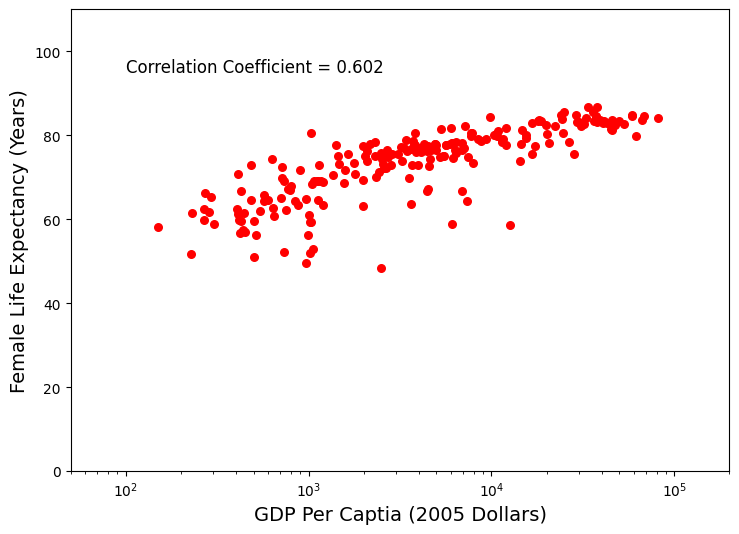

In [ ]:
plt.figure(figsize=(8.5,6))

plt.scatter(gdps,life_female,c='red',s=30)
plt.axis([50,200000,0,110])
plt.xscale('log')
plt.xlabel('GDP Per Captia (2005 Dollars)',fontsize=14)
plt.ylabel('Female Life Expectancy (Years)',fontsize=14)

plt.text(100,95,f'Correlation Coefficient = {np.corrcoef(life_female,gdps)[0,1]:.3f}',fontsize=12)

plt.show()

**Identify the three low outliers on the male life expactancy plot. They will be the three points with the lowest ratio of life expectancy to the log of the GDP.**

In [ ]:
#Note: The command np.argsort(x) is key to this. It returns the array of indices that sort x.
# So: np.argsort(male_ratio)[0:3] returns the indices associated with the three lowest values of this ratio.
male_ratio=life_male/np.log10(gdps)
outlier_indices=np.argsort(male_ratio)[0:3]
print(countries[outlier_indices],gdps[outlier_indices])

['Equatorial Guinea' 'South Africa' 'Swaziland'] [12676.93352636  6090.26831183  2502.45694238]


**Identify the three low outliers on the female life expactancy plot. They will be the three points with the lowest ratio of life expectancy to the log of the GDP.**

In [ ]:
female_ratio=life_female/np.log10(gdps)
outlier_indices=np.argsort(female_ratio)[0:3]
print(countries[outlier_indices], gdps[outlier_indices])

['Swaziland' 'Equatorial Guinea' 'South Africa'] [ 2502.45694238 12676.93352636  6090.26831183]


**Make a final plot of the male life expectancy versus GDP. Label the three outliers.**

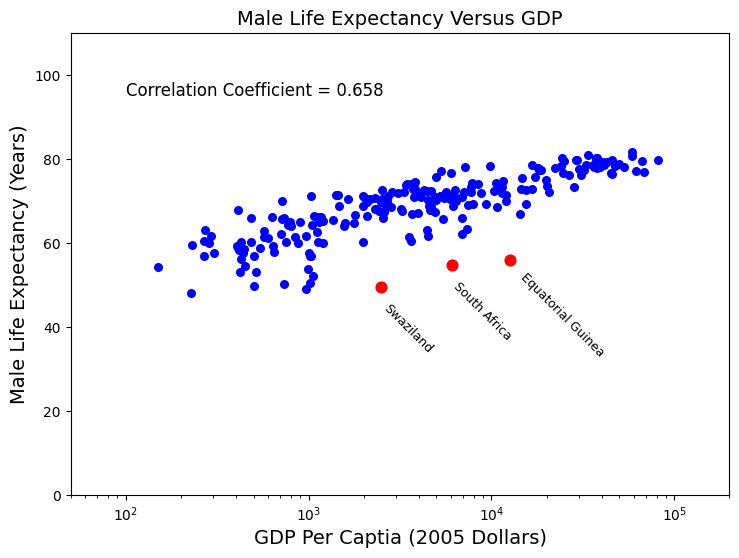

In [ ]:
plt.figure(figsize=(8.5,6))

plt.scatter(gdps,life_male,c='blue',s=30)
plt.scatter(gdps[np.argsort(male_ratio)[0:3]],life_male[np.argsort(male_ratio)[0:3]],c='red',s=60)
plt.axis([50,200000,0,110])
plt.xscale('log')
plt.xlabel('GDP Per Captia (2005 Dollars)',fontsize=14)
plt.ylabel('Male Life Expectancy (Years)',fontsize=14)

plt.text(100,95,f'Correlation Coefficient = {np.corrcoef(life_male,gdps)[0,1]:.3f}',fontsize=12)
plt.text(14000,33,'Equatorial Guinea',fontsize=9,rotation=-45)
plt.text(6000,37,'South Africa',fontsize=9,rotation=-45)
plt.text(2500,34,'Swaziland',fontsize=9,rotation=-45)
plt.title('Male Life Expectancy Versus GDP',fontsize=14)

plt.savefig('drive/My Drive/Colab Notebooks/Notebook12/fig1.pdf')
plt.show()

**Make a final plot of the female life expectancy versus GDP. Label the three outliers.**

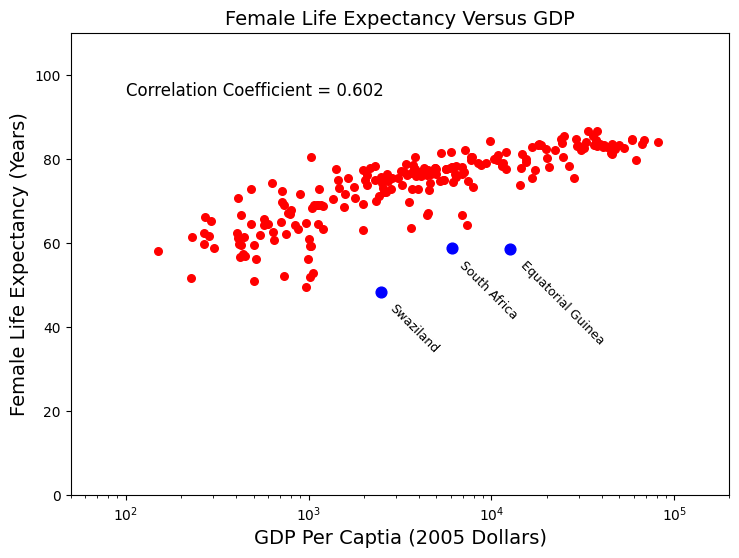

In [ ]:
plt.figure(figsize=(8.5,6))

plt.scatter(gdps,life_female,c='red',s=30)
plt.scatter(gdps[np.argsort(female_ratio)[0:3]],life_female[np.argsort(female_ratio)[0:3]],c='blue',s=60)
plt.axis([50,200000,0,110])
plt.xscale('log')
plt.xlabel('GDP Per Captia (2005 Dollars)',fontsize=14)
plt.ylabel('Female Life Expectancy (Years)',fontsize=14)

plt.text(100,95,f'Correlation Coefficient = {np.corrcoef(life_female,gdps)[0,1]:.3f}',fontsize=12)
plt.text(14000,36,'Equatorial Guinea',fontsize=9,rotation=-45)
plt.text(6500,42,'South Africa',fontsize=9,rotation=-45)
plt.text(2700,34,'Swaziland',fontsize=9,rotation=-45)
plt.title('Female Life Expectancy Versus GDP',fontsize=14)

plt.savefig('drive/My Drive/Colab Notebooks/Notebook12/fig2.pdf')
plt.show()

In [ ]:
# Filter data for the USA
br_data = filtered_data[filtered_data['CountryName'] == 'Brazil']

# Extract the data
forest = br_data['ForestArea']
energy = br_data['EnergyUse']



# Calculate the correlation coefficient
corr_coef = np.corrcoef(forest, energy)[0, 1]

# Create the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(forest, energy, c='blue', alpha=0.7, edgecolors='w', s=100)

# Add labels and title
plt.xlabel('Forest Area (% of land area)', fontsize=12)
plt.ylabel('Energy Use (kg of oil equivalent per capita)', fontsize=12)
plt.title('Forest Area vs. Energy Use in Brazil', fontsize=14)

# Add correlation coefficient as text
plt.text(0.1, 0.9, f'Correlation = {corr_coef:.3f}', transform=plt.gca().transAxes, fontsize=12, color='red')

# Show the plot
plt.show()

In [ ]:
###YOUR CODE FOR YOUR SECOND METHOD HERE!
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SelectKBest, f_regression

# Prepare data
X = df.drop(columns=df.columns[0])  # Features (columns 1-10)
y = df.iloc[:, 0]                   # Target (column 0)

# Method 2B: Linear Regression with largest coefficients
model = LinearRegression()
model.fit(X, y)
coefs = pd.Series(model.coef_, index=X.columns)
top_coefs = coefs.abs().nlargest(2).index.tolist()

print("Method 2A (SelectKBest): Top 2 columns:", top_kbest)
print("Method 2B (Linear Regression Coefficients): Top 2 columns:", top_coefs)

